In this project, we will examine student data and use supervised learning techniques to predict whether a student will drop out. In the education sector, retaining students is vital for the institution's financial stability and for students’ academic success and personal development. A high dropout rate can lead to significant revenue loss, diminished institutional reputation, and lower overall student satisfaction.

You will work with the data in three distinct stages:

1.  Applicant and course information
2.  Student and engagement data
3.  Academic performance data

These stages reflect Study Group’s real-world data journey and how student information has progressed and become available. Additionally, this approach enables you, through data exploration, to support Study Group in better understanding and identifying key metrics to monitor. This approach will also assist you in determining at which stage of the student journey interventions would be most effective.

## Business context
Study Group specialises in providing educational services and resources to students and professionals across various fields. The company's primary focus is on enhancing learning experiences through a range of services, including online courses, tutoring, and educational consulting. By leveraging cutting-edge technology and a team of experienced educators, Study Group aims to bridge the gap between traditional learning methods and the evolving needs of today's learners.

Study Group serves its university partners by establishing strategic partnerships to enhance the universities’ global reach and diversity. It supports the universities in their efforts to attract international students, thereby enriching the cultural and academic landscape of their campuses. It works closely with university faculty and staff to ensure that the universities are prepared and equipped to welcome and support a growing international student body. Its partnership with universities also offers international students a seamless transition into their chosen academic environment.

Study Group runs several International Study Centres across the UK and Dublin in partnership with universities with the aim of preparing a pipeline of talented international students from diverse backgrounds for degree study. These centres help international students adapt to the academic, cultural, and social aspects of studying abroad. This is achieved by improving conversational and subject-specific language skills and academic readiness before students progress to a full degree programme at university.

Through its comprehensive suite of services, it supports learners and universities at every stage of their educational journey, from high school to postgraduate studies. Its approach is tailored to meet the unique needs of each learner, offering personalised learning paths and flexible scheduling options to accommodate various learning styles and commitments.

Study Group's services are designed to be accessible and affordable, making quality education a reality for many individuals. By focusing on the integration of technology and personalised learning, the company aims to empower learners to achieve their full potential and succeed in their academic and professional pursuits. Study Group is at the forefront of transforming how people learn and grow through its dedication to innovation and excellence.

Study Group has provided you with 3 data sets.



# Stage 1 data

In [ ]:
!pip install gdown
!pip install keras-tuner
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.9 MB/s eta 0:00:00


In [ ]:
!gdown ''

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score,accuracy_score,classification_report
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

## Data Loading & Exploration

In [ ]:
file_url = ''
stage1_data = pd.read_csv(file_url)

In [ ]:
print(f"view data shape : \n{stage1_data.shape}")
print(f"view data frame : \n{stage1_data.head()}")

In [ ]:
stage1_data.head().T

In [ ]:
print(f"duplicate values : \n{stage1_data.duplicated().sum()}")

duplicate values : 
0


## Data Cleaning & Preprocessing

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [ ]:
def drop_unwanted_columns(data):
    """Drop known leakage and ID columns."""
    manual_drop_cols = [
        'LearnerCode',
        'ProgressionDegree',
        'ProgressionUniversity',
        'CompletedCourse'
    ]
    return data.drop(columns=manual_drop_cols, errors='ignore')

*   LearnerCode as it's ID column
*   ProgressionDegree & ProgressionUniversity are both future info and not relavnt to stage 1 also >200 unique values. ( those values hint the dropout decision )
* CompletedCourse target variable




### Handling Missing Values

In [ ]:
missing_percent = stage1_data.isna().mean() * 100
print(f"missing values : \n{missing_percent.sort_values(ascending=False)}")


In [ ]:
def remove_high_missing_columns(data, threshold=50):
    """Remove columns with >50% missing values."""
    missing_percent = data.isna().mean() * 100
    high_missing_cols = missing_percent[missing_percent > threshold].index.tolist()
    cleaned_data = data.drop(columns=high_missing_cols)
    print("\nColumns with >{}% missing removed: {}".format(threshold, high_missing_cols))
    return cleaned_data

### High Cardinality Handling

In [ ]:
stage1_data.nunique().sort_values(ascending=False)

In [ ]:
def remove_high_cardinality_columns(data, threshold=200):
    #Remove high-cardinality categorical columns (>200 unique values)
    categorical_cols = data.select_dtypes(include='object').columns
    high_cardinality_cols = [
        col for col in categorical_cols if data[col].nunique() > threshold
    ]
    cleaned_data = data.drop(columns=high_cardinality_cols)
    print("High-cardinality columns removed:", high_cardinality_cols)
    return cleaned_data

### Feature Engineering

In [ ]:
def calculate_age(data,DateofBirth):
    """Calculate age from Date of Birth."""
    data['DOB'] = pd.to_datetime(DateofBirth, dayfirst=True, errors='coerce')
    data['Age'] = ((pd.Timestamp.today() - data['DOB']).dt.days / 365.25).round(0)
    data['Age'] = data['Age'].astype('Int64')
    data.drop(columns=['DOB'], inplace=True)
    return data

In [ ]:
def convert_boolean_to_integer(data):
    #Convert boolean columns to integers.
    if 'IsFirstIntake' in data.columns:
        data['IsFirstIntake'] = data['IsFirstIntake'].astype(int)
    return data

### Feature Encoding

In [ ]:
print(stage1_data['CourseLevel'].unique())

['Pre-Masters' 'Foundation' 'International Year Two'
 'International Year One']


In [ ]:
def ordinal_encode_course_level(data):
    """Ordinal encode the CourseLevel column."""
    course_order = {
        'Foundation': 0,
        'International Year One': 1,
        'International Year Two': 2,
        'Pre-Masters': 3
    }
    if 'CourseLevel' in data.columns:
        data['CourseLevel'] = data['CourseLevel'].map(course_order)
    return data

In [ ]:
def one_hot_encode_categorical(data):
    """One-hot encode remaining categorical columns."""
    categorical_cols = data.select_dtypes(include='object').columns
    return pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [ ]:
def clean_and_preprocess_data(data):
    #Main function to clean and preprocess the data.
    cleaned_data = data.copy()
    cleaned_data = drop_unwanted_columns(cleaned_data)
    cleaned_data = remove_high_missing_columns(cleaned_data)
    cleaned_data = remove_high_cardinality_columns(cleaned_data)
    cleaned_data = calculate_age(cleaned_data,data['DateofBirth'])
    cleaned_data = convert_boolean_to_integer(cleaned_data)
    cleaned_data = ordinal_encode_course_level(cleaned_data)
    cleaned_data = one_hot_encode_categorical(cleaned_data)
    return cleaned_data

In [ ]:
stage1_data_cleaned = clean_and_preprocess_data(stage1_data)


Columns with >50% missing removed: ['DiscountType', 'HomeState']
High-cardinality columns removed: ['DateofBirth', 'HomeCity']


In [ ]:
stage1_data_cleaned.head()

In [ ]:
print("\nFinal shape:")
print(stage1_data_cleaned.shape)


Final shape:
(25059, 350)


## Target Variable

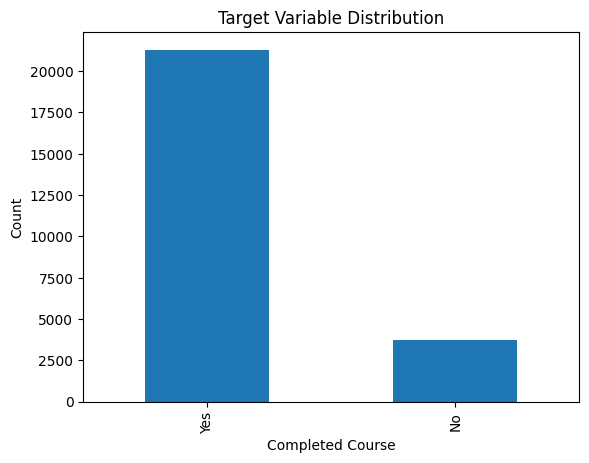

,proportion
CompletedCourse,
Yes,85.019354
No,14.980646


In [ ]:
stage1_data['CompletedCourse'].value_counts().plot(kind='bar')

plt.title('Target Variable Distribution')
plt.xlabel('Completed Course')
plt.ylabel('Count')

plt.show()
stage1_data['CompletedCourse'].value_counts(normalize=True) * 100

The target variable CompletedCourse is clearly imbalanced, with approximately 85.0% of students completing the course and only 15.0% not completing it. This indicates that dropout cases represent a minority class in the dataset.

## Train-Test Split

In [ ]:
print(stage1_data['CompletedCourse'].unique())

['Yes' 'No']


In [ ]:
def map_completed_course(data):
    """Map the 'CompletedCourse' column to binary values."""
    if 'CompletedCourse' in data.columns:
        return data['CompletedCourse'].map({'No': 0, 'Yes': 1})
    else:
        raise ValueError("Column 'CompletedCourse' does not exist in the provided DataFrame.")

In [ ]:
y = map_completed_course(stage1_data)
print(y.value_counts(dropna=False))

CompletedCourse
1    21305
0     3754
Name: count, dtype: int64


In [ ]:
def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
    """Split the data into training, validation, and test sets.

    Args:
        X: Feature set.
        y: Target variable.
        test_size : Proportion of the data to be used as the test set.
        val_size : Proportion of the training data to be used as the validation set.
        random_state : Random seed for reproducibility.

    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test: Split datasets.
    """
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=y)

    # Split the training set into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                      test_size=val_size,
                                                      random_state=random_state,
                                                      stratify=y_train)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
X_train_s1, X_val_s1, X_test_s1, y_train_s1, y_val_s1, y_test_s1 = split_data(stage1_data_cleaned, y)

In [ ]:
# Print value counts
print("Stage 1 - y_train Distribution:\n", y_train_s1.value_counts(normalize=True))
print("\nStage 1 - y_val Distribution:\n", y_val_s1.value_counts(normalize=True))
print("\nStage 1 - y_test Distribution:\n", y_test_s1.value_counts(normalize=True))

# Calculate scale_pos_weight
scale_pos_weight_s1 = y_train_s1.value_counts()[0] / y_train_s1.value_counts()[1]
print("\nStage 1 Scale Pos Weight:", scale_pos_weight_s1)


Stage 1 - y_train Distribution:
 CompletedCourse
1    0.850183
0    0.149817
Name: proportion, dtype: float64

Stage 1 - y_val Distribution:
 CompletedCourse
1    0.850374
0    0.149626
Name: proportion, dtype: float64

Stage 1 - y_test Distribution:
 CompletedCourse
1    0.85016
0    0.14984
Name: proportion, dtype: float64

Stage 1 Scale Pos Weight: 0.1762174848425582


The class distribution remained consistent across all subsets, with approximately 85% of students completing the course and 15% not completing it.

 Scale Pos Weight - This value indicates that the model will give approximately : 1/0.176=5.68 times more importance to the minority class (not completed) during training, improving its predictive accuracy for that group.

## Model Building

### XGBoost Model

#### Basic Model

In [ ]:
def train_xgb_basic_model(X_train, y_train):
    """Train the basic XGBoost model."""
    xgb_model = xgb.XGBClassifier(random_state=42)
    xgb_model.fit(X_train, y_train)
    print("Basic XGBoost model has been fitted successfully.")
    return xgb_model

In [ ]:
def evaluate_xgb_model(y_test, y_test_pred, y_test_prob):
    """Evaluate the model performance and print metrics."""
    accuracy = accuracy_score(y_test, y_test_pred)
    conf_matrix = confusion_matrix(y_test, y_test_pred)
    class_report = classification_report(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_prob)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)

    print("Model Metrics:")
    print("Accuracy:", accuracy)
    print("Confusion Matrix:\n", conf_matrix)
    print("Classification Report:\n", class_report)
    print("AUC:", auc)

    return accuracy, conf_matrix, precision, recall, auc

In [ ]:
print("Stage 1 - Basic Model:")
basic_model_s1 = train_xgb_basic_model(X_train_s1, y_train_s1)

Stage 1 - Basic Model:
Basic XGBoost model has been fitted successfully.


#### Basic Model Evaluation

In [ ]:
# Evaluate Basic Model for Stage 1
y_test_pred_basic_s1 = basic_model_s1.predict(X_test_s1)
y_test_prob_basic_s1 = basic_model_s1.predict_proba(X_test_s1)[:, 1]
baseline_metrics_xgb_s1 = evaluate_xgb_model(y_test_s1, y_test_pred_basic_s1, y_test_prob_basic_s1)

Model Metrics:
Accuracy: 0.8938547486033519
Confusion Matrix:
 [[ 395  356]
 [ 176 4085]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.53      0.60       751
           1       0.92      0.96      0.94      4261

    accuracy                           0.89      5012
   macro avg       0.81      0.74      0.77      5012
weighted avg       0.89      0.89      0.89      5012

AUC: 0.8782580747378681


* 89.3% of the predictions made by the model are correct.
* TN: 395 correctly predicted as class 0
* FP: 356 incorrectly predicted as class 1
* FN: 176 incorrectly predicted as class 0
* TTP: 4085 correctly predicted as class 1
* precision Class 0: 0.69 (Out of all predicted as class 0, 70% were correct)
* precision Class 1: 0.92 (Out of all predicted as class 1, 92% were correct)
* Recall Class 0: 0.53 (Of all actual class 0 instances, 52% were correctly identified)
* Recall Class 1: 0.96 (Of all actual class 1 instances, 96% were correctly identified)
* F1-score Class 0: 0.60 (Harmonic mean of precision and recall for class 0)
* F1-score Class 1: 0.94 (Harmonic mean for class 1)
* AUC of 0.87 indicates a strong ability of the model to distinguish between the two classes.


#### Tuned Model

In [ ]:
def tune_xgb_model(X_train, y_train):
    """Perform hyperparameter tuning and return the optimized XGBoost model."""
    xgb_model = xgb.XGBClassifier(random_state=42)
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'n_estimators': [50, 100, 150, 200]
    }

    grid_search = GridSearchCV(estimator=xgb_model,
                               param_grid=param_grid,
                               scoring='roc_auc',
                               cv=3,
                               verbose=1,
                               n_jobs=-1)

    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    print("Best Parameters:", best_params)
    print("Best Cross-Validation AUC Score:", best_score)

    # Train the best model
    best_xgb_model = xgb.XGBClassifier(**best_params, random_state=42)
    best_xgb_model.fit(X_train, y_train)

    return best_xgb_model

In [ ]:
print("\nStage 1 - Tuned Model:")
tuned_model_s1 = tune_xgb_model(X_train_s1, y_train_s1)


Stage 1 - Tuned Model:
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}
Best Cross-Validation AUC Score: 0.8751761792805568


The tuned XGBoost model achieved a cross-validation AUC score of 0.8752 using a learning rate of 0.2, maximum depth of 5, and 50 estimators, indicating strong predictive performance in identifying students at risk of dropping out.

#### Tuned Model Evaluation

In [ ]:
y_test_pred_tuned_s1 = tuned_model_s1.predict(X_test_s1)
y_test_prob_tuned_s1 = tuned_model_s1.predict_proba(X_test_s1)[:, 1]
tuned_metrics_xgb_s1 = evaluate_xgb_model(y_test_s1, y_test_pred_tuned_s1, y_test_prob_tuned_s1)

Model Metrics:
Accuracy: 0.8930566640063847
Confusion Matrix:
 [[ 373  378]
 [ 158 4103]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.50      0.58       751
           1       0.92      0.96      0.94      4261

    accuracy                           0.89      5012
   macro avg       0.81      0.73      0.76      5012
weighted avg       0.88      0.89      0.89      5012

AUC: 0.8782532310045185


hyperparameter tuning did not significantly improve the metrics, it maintained a similar performance level. This could indicate that the initial model was already well-tuned, or that further tuning may be needed for improvement.

####  Feature Importance & Insights

In [ ]:
def plot_feature_importance(model, X_train, top_n=10):
    """Plot the feature importance of the given model.

    Args:
        model: The trained model.
        X_train: Training features.
        top_n: Number of top features to display.
    """
    importance = model.feature_importances_
    feature_names = X_train.columns

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    # Limit to top N features for visualization
    top_features = feature_importance_df.head(top_n)

    # Plotting Feature Importance
    plt.figure(figsize=(10, 6))
    plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
    plt.xlabel('Importance Score')
    plt.title(f'Top {top_n} Feature Importance')
    plt.gca().invert_yaxis()
    plt.show()

In [ ]:
plot_feature_importance(tuned_model_s1, X_train_s1)

nationality-related features, particularly Nationality_Bangladeshi, Nationality_Indian, and Nationality_Pakistani, are among the most significant, suggesting that student nationality may play a crucial role in shaping educational outcomes. Additionally, the importance of various center names, such as CentreName_ISC_Sheffield and CentreName_ISC_London, indicates that the institution's environment can significantly impact student success. Other notable features include CourseLevel and BookingType_Direct, emphasizing that both the course's complexity and the method of enrollment are critical factors. This insight can guide targeted strategies for engaging different student demographics and enhancing their educational experiences.

### Neural Network Model

#### Data Standardisation

In [ ]:
def preprocess_data(X):
    """Scale the features using StandardScaler."""
    scaler = StandardScaler()
    return scaler.fit_transform(X)

#### Model Creation

In [ ]:
def create_nn_model(input_shape, num_hidden_layers, num_neurons, activation, optimizer, dropout_rate,reg):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    for _ in range(num_hidden_layers):
        model.add(layers.Dense(num_neurons, activation=activation,kernel_regularizer=l1_l2(reg)))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))  # binary classification

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy',
        keras.metrics.AUC(name='auc')])
    return model

#### Basic Model

In [ ]:
# Baseline model without hyperparameter tuning
def baseline_nn_model(X_train, y_train):
    dropout_rate = 0.3
    model = create_nn_model(
        X_train.shape[1:],
        num_hidden_layers=2,
        num_neurons=64,
        activation='relu',
        optimizer='adam',
        dropout_rate=dropout_rate,
        reg=1e-4
    )
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
    return model, history

#### Tuned Model

In [ ]:
# Hyperparameter tuning
def tune_nn_model(X_train, y_train):

    def model_builder(hp):
      input_shape = (X_train.shape[1],)
      num_hidden_layers = hp.Int('num_hidden_layers', min_value=1, max_value=3)
      num_neurons = hp.Int('num_neurons', min_value=32, max_value=128, step=32)
      activation = hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])
      optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
      dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
      reg = hp.Float('reg', min_value=1e-4, max_value=1e-2, sampling='log')

      return create_nn_model(input_shape, num_hidden_layers, num_neurons, activation, optimizer,dropout_rate,reg)

    tuner = kt.RandomSearch(
        model_builder,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory='/content/my_dir',
        project_name='stage1_NN_hyperparameter_tuning'
    )

    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2)

    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    tuner.search(X_train_split, y_train_split, epochs=100,batch_size=32, validation_data=(X_val_split, y_val_split), callbacks=[early_stopping])

    best_hyperparameters = tuner.get_best_hyperparameters()[0]

    best_model = create_nn_model(
        X_train.shape[1:],
        best_hyperparameters.get('num_hidden_layers'),
        best_hyperparameters.get('num_neurons'),
        best_hyperparameters.get('activation'),
        best_hyperparameters.get('optimizer'),
        best_hyperparameters.get('dropout_rate'),
        best_hyperparameters.get('reg')
    )

    history = best_model.fit(
          X_train,
          y_train,
          epochs=100,
          batch_size=32,
          validation_data=(X_val_split, y_val_split),
          callbacks=[early_stopping],
          verbose=0
      )
    return best_model,history

#### Evaluation

In [ ]:
def evaluate_nn_model(model, X_test, y_test):

    # Evaluate the model using the test data
    loss, accuracy, auc_metric = model.evaluate(X_test, y_test, verbose=0)
    y_pred = model.predict(X_test)
    y_pred_class = (y_pred > 0.5).astype(int)

    precision = precision_score(y_test, y_pred_class)
    recall = recall_score(y_test, y_pred_class)
    auc = roc_auc_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred_class)

    return accuracy,cm, precision, recall, auc

In [ ]:
def plot_loss_curves(history, title):

    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
def run_experiment(X, y):
    # Preprocess data
    X_scaled = preprocess_data(X)

    # Split data
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y, test_size=0.2)

    # Train baseline model
    baseline_model_instance, baseline_history = baseline_nn_model(X_train_split, y_train_split)
    #Plot curve
    plot_loss_curves(baseline_history,'Baseline Neural Network Loss Curves')

    # Tune model
    tuned_model_instance, tuned_history = tune_nn_model(X_train_split, y_train_split)
    #Plot curve
    plot_loss_curves(tuned_history,'Tuned Neural Network Loss Curves')

    # Evaluate models
    baseline_metrics = evaluate_nn_model(baseline_model_instance, X_test_split, y_test_split)
    tuned_metrics = evaluate_nn_model(tuned_model_instance, X_test_split, y_test_split)

    return baseline_metrics, tuned_metrics

In [ ]:
def print_metrics(name, metrics):
    print(f"{name} Metrics:")
    print(f"Accuracy: {metrics[0]:.4f}")
    print("Confusion Matrix:\n", metrics[1])
    print(f"Precision: {metrics[2]:.4f}")
    print(f"Recall: {metrics[3]:.4f}")
    print(f"AUC: {metrics[4]:.4f}\n")

Trial 10 Complete [00h 00m 41s]
val_accuracy: 0.8964322805404663

Best val_accuracy So Far: 0.900588870048523
Total elapsed time: 00h 08m 19s


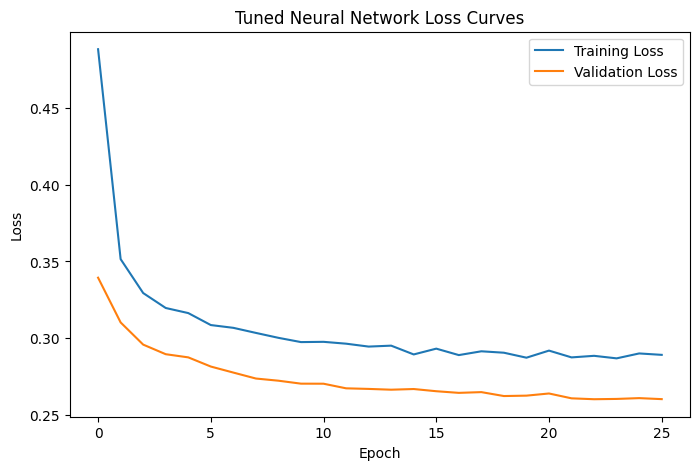

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
baseline_metrics_s1, tuned_metrics_s1 = run_experiment(X_train_s1, y_train_s1)

In [ ]:
print_metrics("Baseline Model Stage 1", baseline_metrics_s1)
print_metrics("Tuned Model Stage 1", tuned_metrics_s1)

Baseline Model Stage 1 Metrics:
Accuracy: 0.8980
Confusion Matrix:
 [[ 253  255]
 [ 113 2988]]
Precision: 0.9214
Recall: 0.9636
AUC: 0.8575

Tuned Model Stage 1 Metrics:
Accuracy: 0.8969
Confusion Matrix:
 [[ 255  253]
 [ 119 2982]]
Precision: 0.9218
Recall: 0.9616
AUC: 0.8604



The tuned neural network shows very similar performance to the baseline model, with only marginal differences across all metrics. While the tuned model slightly improves precision and AUC, the baseline model achieves marginally higher accuracy and recall. Since recall is particularly important for identifying students at risk of dropping out, the baseline model may offer slightly better practical value despite the minimal gains from hyperparameter tuning.

# Stage 2 data

## Data Loading & Exploration

In [ ]:
!gdown ''

In [ ]:
# File URL
file2_url = ''
stage2_data = pd.read_csv(file2_url)

In [ ]:
print(f"view data shape : \n{stage2_data.shape}")
print(f"view data frame : \n{stage2_data.head()}")

In [ ]:
stage2_data.head().T

In [ ]:
print(f"duplicate values : \n{stage2_data.duplicated().sum()}")

duplicate values : 
0


## Data Cleaning & Preprocessing

**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
#The additional columns have a small percentage of missing values, approximately 0.8%. Therefore, we can consider dropping these rows.
stage2_data['UnauthorisedAbsenceCount'] = (
    stage2_data['UnauthorisedAbsenceCount']
    .fillna(0)
)

stage2_data['AuthorisedAbsenceCount'] = (
    stage2_data['AuthorisedAbsenceCount']
    .fillna(0)
)

In [ ]:
#using function have defined during stage 1 as generic functions
stage2_data_cleaned = clean_and_preprocess_data(stage2_data)


Columns with >50% missing removed: ['DiscountType', 'HomeState']
High-cardinality columns removed: ['DateofBirth', 'HomeCity']


In [ ]:
print("\nFinal shape:")
print(stage2_data_cleaned.shape)


Final shape:
(25059, 352)


In [ ]:
stage2_data_cleaned.isna().sum()

## Train-Test Split

In [ ]:
y = map_completed_course(stage1_data)
print(y.value_counts(dropna=False))

CompletedCourse
1    21305
0     3754
Name: count, dtype: int64


In [ ]:
X_train_s2, X_val_s2, X_test_s2, y_train_s2, y_val_s2, y_test_s2 = split_data(stage2_data_cleaned, y)

In [ ]:
print("Stage 2 - y_train Distribution:\n", y_train_s2.value_counts(normalize=True))
print("\nStage 2 - y_val Distribution:\n", y_val_s2.value_counts(normalize=True))
print("\nStage 2 - y_test Distribution:\n", y_test_s2.value_counts(normalize=True))

# Calculate scale_pos_weight
scale_pos_weight_s2 = y_train_s2.value_counts()[0] / y_train_s2.value_counts()[1]
print("\nStage 2 Scale Pos Weight:", scale_pos_weight_s2)

Stage 2 - y_train Distribution:
 CompletedCourse
1    0.850183
0    0.149817
Name: proportion, dtype: float64

Stage 2 - y_val Distribution:
 CompletedCourse
1    0.850374
0    0.149626
Name: proportion, dtype: float64

Stage 2 - y_test Distribution:
 CompletedCourse
1    0.85016
0    0.14984
Name: proportion, dtype: float64

Stage 2 Scale Pos Weight: 0.1762174848425582


## Model Building

### XGBoost Model

Basic Model

In [ ]:
print("Stage 2 - Basic Model:")
basic_model_s2 = train_xgb_basic_model(X_train_s2, y_train_s2)

Stage 2 - Basic Model:
Basic XGBoost model has been fitted successfully.


Evaluate Basic Model

In [ ]:
# Evaluate Basic Model for Stage 2
y_test_pred_basic_s2 = basic_model_s2.predict(X_test_s2)
y_test_prob_basic_s2 = basic_model_s2.predict_proba(X_test_s2)[:, 1]
# Evaluate the model
baseline_metrics_xgb_s2 = evaluate_xgb_model(y_test_s2, y_test_pred_basic_s2, y_test_prob_basic_s2)

Model Metrics:
Accuracy: 0.9096169193934557
Confusion Matrix:
 [[ 458  293]
 [ 160 4101]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.61      0.67       751
           1       0.93      0.96      0.95      4261

    accuracy                           0.91      5012
   macro avg       0.84      0.79      0.81      5012
weighted avg       0.90      0.91      0.91      5012

AUC: 0.910561869943572


A strong baseline XGBoost model was achieved on the Stage 2 dataset, reaching an accuracy of 90.96% and an AUC of 0.911. The model shows good class separation, particularly for the majority class (students who complete the course), while performance on the minority class is lower but still reasonable given the class imbalance.

Tuned Model

In [ ]:
print("\nStage 2 - Tuned Model:")
tuned_model_s2 = tune_xgb_model(X_train_s2, y_train_s2)


Stage 2 - Tuned Model:
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best Cross-Validation AUC Score: 0.9132012014958425


The tuned XGBoost model for Stage 2 achieved a best cross-validation AUC score of 0.9132 using a learning rate of 0.2, maximum depth of 5, and 100 estimators. This represents a slight improvement over the baseline model, indicating that hyperparameter tuning enhanced the model’s ability to distinguish between students who complete and those who drop out.

Evaluate Tuned Model

In [ ]:
y_test_pred_tuned_s2 = tuned_model_s2.predict(X_test_s2)
y_test_prob_tuned_s2 = tuned_model_s2.predict_proba(X_test_s2)[:, 1]
tuned_metrics_xgb_s2 = evaluate_xgb_model(y_test_s2, y_test_pred_tuned_s2, y_test_prob_tuned_s2)

Model Metrics:
Accuracy: 0.9080207501995211
Confusion Matrix:
 [[ 442  309]
 [ 152 4109]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.59      0.66       751
           1       0.93      0.96      0.95      4261

    accuracy                           0.91      5012
   macro avg       0.84      0.78      0.80      5012
weighted avg       0.90      0.91      0.90      5012

AUC: 0.9098037475496178


Feature Importance

In [ ]:
plot_feature_importance(tuned_model_s2, X_train_s2)

The feature "Nationality_Bangladeshi" emerges as the most significant predictor, followed closely by "Nationality_Indian" and "Nationality_Pakistani." This indicates that nationality plays a crucial role in determining the outcomes of the model, likely reflecting the demographic factors influencing the target variable. Other notable features include various center names and the booking type, suggesting that the location of service and the method of booking also significantly impact the results. Understanding these feature importances can guide further analysis and strategic decisions in the relevant domain.

### Neural Network

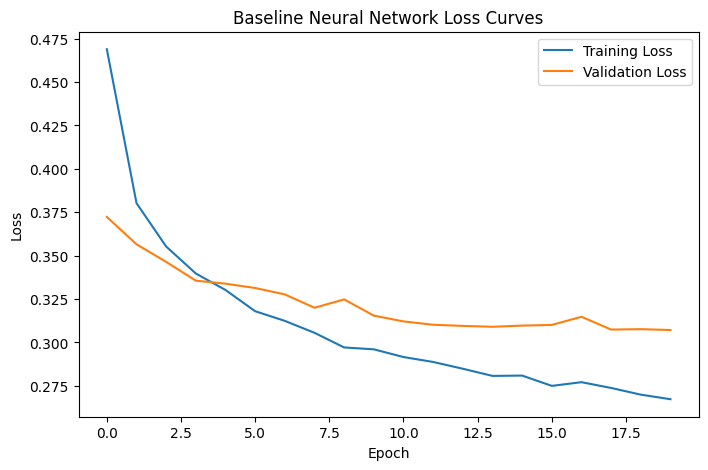

Reloading Tuner from /content/my_dir/stage1_NN_hyperparameter_tuning/tuner0.json


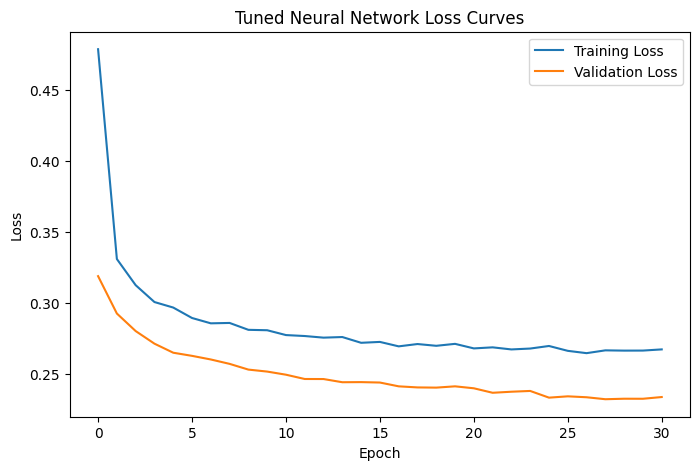

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
baseline_metrics_s2, tuned_metrics_s2 = run_experiment(X_train_s2, y_train_s2)

In [ ]:
print_metrics("Baseline Model Stage 2", baseline_metrics_s2)
print_metrics("Tuned Model Stage 2", tuned_metrics_s2)

Baseline Model Stage 2 Metrics:
Accuracy: 0.9030
Confusion Matrix:
 [[ 312  239]
 [ 111 2947]]
Precision: 0.9250
Recall: 0.9637
AUC: 0.8991

Tuned Model Stage 2 Metrics:
Accuracy: 0.9016
Confusion Matrix:
 [[ 315  236]
 [ 119 2939]]
Precision: 0.9257
Recall: 0.9611
AUC: 0.9065



The tuned Neural Network model for Stage 2 shows very similar performance to the baseline model. While accuracy remains almost unchanged, the tuned model slightly improves AUC and precision, indicating better class discrimination. However, this comes with a small decrease in recall, which is important for identifying students at risk of dropout. Overall, both models perform comparably, with no clear advantage from hyperparameter tuning.

# Stage 3 data

In [ ]:
!gdown ''

In [ ]:
# File URL
file3_url = ''
stage3_data = pd.read_csv(file3_url)

In [ ]:
print(f"view data shape : \n{stage3_data.shape}")
print(f"view data frame : \n{stage3_data.head()}")

In [ ]:
stage3_data.head().T

In [ ]:
print(f"duplicate values : \n{stage3_data.duplicated().sum()}")

duplicate values : 
0


In [ ]:
stage3_data.isna().sum()

## Data Cleaning & Preprocessing

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [ ]:
cols = [
    'UnauthorisedAbsenceCount',
    'AuthorisedAbsenceCount',
    'AssessedModules',
    'PassedModules',
    'FailedModules'
]

for col in cols:
    stage3_data[col] = stage3_data[col].fillna(0)

In [ ]:
#using function have defined during stage 1 as generic functions
stage3_data_cleaned = clean_and_preprocess_data(stage3_data)


Columns with >50% missing removed: ['DiscountType', 'HomeState']
High-cardinality columns removed: ['DateofBirth', 'HomeCity']


In [ ]:
print("\nFinal shape:")
print(stage3_data_cleaned.shape)


Final shape:
(25059, 355)


In [ ]:
stage3_data_cleaned.isna().sum()

## Train-Test Split

In [ ]:
y = map_completed_course(stage3_data)
print(y.value_counts(dropna=False))

CompletedCourse
1    21305
0     3754
Name: count, dtype: int64


In [ ]:
X_train_s3, X_val_s3, X_test_s3, y_train_s3, y_val_s3, y_test_s3 = split_data(stage3_data_cleaned, y)

In [ ]:
print("Stage 3 - y_train Distribution:\n", y_train_s3.value_counts(normalize=True))
print("\nStage 3 - y_val Distribution:\n", y_val_s3.value_counts(normalize=True))
print("\nStage 3 - y_test Distribution:\n", y_test_s3.value_counts(normalize=True))

# Calculate scale_pos_weight
scale_pos_weight_s3 = y_train_s3.value_counts()[0] / y_train_s3.value_counts()[1]
print("\nStage 3 Scale Pos Weight:", scale_pos_weight_s3)

Stage 3 - y_train Distribution:
 CompletedCourse
1    0.850183
0    0.149817
Name: proportion, dtype: float64

Stage 3 - y_val Distribution:
 CompletedCourse
1    0.850374
0    0.149626
Name: proportion, dtype: float64

Stage 3 - y_test Distribution:
 CompletedCourse
1    0.85016
0    0.14984
Name: proportion, dtype: float64

Stage 3 Scale Pos Weight: 0.1762174848425582


## Model Building

### XGBoost Model

Basic Model

In [ ]:
print("Stage 3 - Basic Model:")
basic_model_s3 = train_xgb_basic_model(X_train_s3, y_train_s3)

Stage 3 - Basic Model:
Basic XGBoost model has been fitted successfully.


Evaluate Basic Model

In [ ]:
# Evaluate Basic Model for Stage 3
y_test_pred_basic_s3 = basic_model_s3.predict(X_test_s3)
y_test_prob_basic_s3 = basic_model_s3.predict_proba(X_test_s3)[:, 1]
# Evaluate the model
baseline_metrics_xgb_s3 = evaluate_xgb_model(y_test_s3, y_test_pred_basic_s3, y_test_prob_basic_s3)

Model Metrics:
Accuracy: 0.9906225059856345
Confusion Matrix:
 [[ 722   29]
 [  18 4243]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       751
           1       0.99      1.00      0.99      4261

    accuracy                           0.99      5012
   macro avg       0.98      0.98      0.98      5012
weighted avg       0.99      0.99      0.99      5012

AUC: 0.9989350036609249


The baseline XGBoost model on the Stage 3 dataset achieved excellent performance, with an accuracy of 99.06% and an AUC of 0.999. The model demonstrates near-perfect class separation, correctly identifying both students who complete and those at risk of dropout. This strong performance suggests that the additional Stage 3 features provide highly predictive information, significantly improving model effectiveness compared to earlier stages.

Tuned Model

In [ ]:
print("\nStage 3 - Tuned Model:")
tuned_model_s3 = tune_xgb_model(X_train_s3, y_train_s3)


Stage 3 - Tuned Model:
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150}
Best Cross-Validation AUC Score: 0.9989692802088269


The tuned XGBoost model for Stage 3 achieved an extremely high cross-validation AUC score of 0.99897 using a learning rate of 0.2, maximum depth of 3, and 150 estimators. This indicates near-perfect predictive performance, showing that the model is highly effective at distinguishing between students who complete the course and those who drop out when enriched Stage 3 features are included.

Evaluate Tuned Model

In [ ]:
y_test_pred_tuned_s3 = tuned_model_s3.predict(X_test_s3)
y_test_prob_tuned_s3 = tuned_model_s3.predict_proba(X_test_s3)[:, 1]
tuned_metrics_xgb_s3 = evaluate_xgb_model(y_test_s3, y_test_pred_tuned_s3, y_test_prob_tuned_s3)

Model Metrics:
Accuracy: 0.9902234636871509
Confusion Matrix:
 [[ 722   29]
 [  20 4241]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       751
           1       0.99      1.00      0.99      4261

    accuracy                           0.99      5012
   macro avg       0.98      0.98      0.98      5012
weighted avg       0.99      0.99      0.99      5012

AUC: 0.9989934409600467


Feature Importance

In [ ]:
plot_feature_importance(tuned_model_s3, X_train_s3)

"PassedModules" stands out as the most important feature, followed by "AssessedModules." The center names, such as "CentreName_ISC_Kingston" and "CentreName_ISC_LJMU," also play significant roles. Other notable features include specific course names, indicating that both module performance and educational institution impact outcomes. Understanding these features can help in refining educational strategies and interventions.

### Neural Network

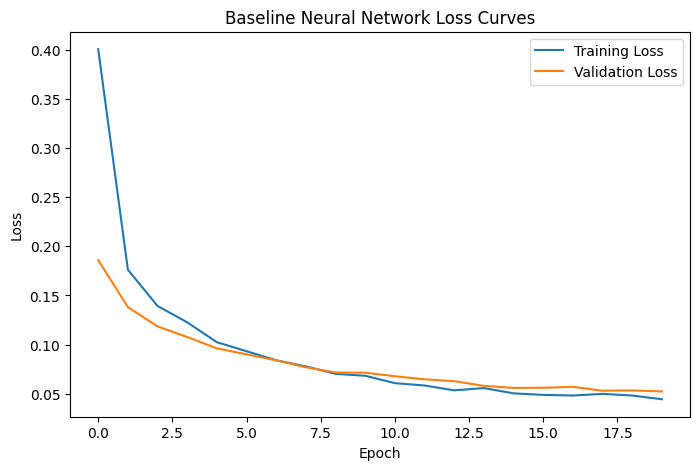

Reloading Tuner from /content/my_dir/stage1_NN_hyperparameter_tuning/tuner0.json


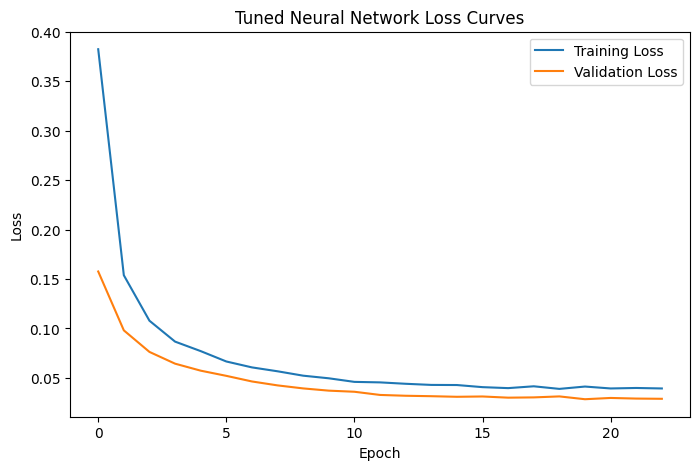

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
baseline_metrics_s3, tuned_metrics_s3 = run_experiment(X_train_s3, y_train_s3)

In [ ]:
print_metrics("Baseline Model Stage 3", baseline_metrics_s3)
print_metrics("Tuned Model Stage 3", tuned_metrics_s3)

Baseline Model Stage 3 Metrics:
Accuracy: 0.9900
Confusion Matrix:
 [[ 524   28]
 [   8 3049]]
Precision: 0.9909
Recall: 0.9974
AUC: 0.9994

Tuned Model Stage 3 Metrics:
Accuracy: 0.9903
Confusion Matrix:
 [[ 530   22]
 [  13 3044]]
Precision: 0.9928
Recall: 0.9957
AUC: 0.9994



# Final Results

In [ ]:
final_results = pd.DataFrame({
    "NN Stage 1 Baseline": [
        baseline_metrics_s1[0], baseline_metrics_s1[2], baseline_metrics_s1[3], baseline_metrics_s1[4]
    ],

    "NN Stage 1 Tuned": [
        tuned_metrics_s1[0], tuned_metrics_s1[2], tuned_metrics_s1[3], tuned_metrics_s1[4]
    ],

    "NN Stage 2 Baseline": [
        baseline_metrics_s2[0], baseline_metrics_s2[2], baseline_metrics_s2[3], baseline_metrics_s2[4]
    ],

    "NN Stage 2 Tuned": [
        tuned_metrics_s2[0], tuned_metrics_s2[2], tuned_metrics_s2[3], tuned_metrics_s2[4]
    ],

    "NN Stage 3 Baseline": [
        baseline_metrics_s3[0], baseline_metrics_s3[2], baseline_metrics_s3[3], baseline_metrics_s3[4]
    ],

    "NN Stage 3 Tuned": [
        tuned_metrics_s3[0], tuned_metrics_s3[2], tuned_metrics_s3[3], tuned_metrics_s3[4]
    ],

    "XGB Stage 1 Baseline": [
        baseline_metrics_xgb_s1[0], baseline_metrics_xgb_s1[2], baseline_metrics_xgb_s1[3], baseline_metrics_xgb_s1[4]
    ],

    "XGB Stage 1 Tuned": [
        tuned_metrics_xgb_s1[0], tuned_metrics_xgb_s1[2], tuned_metrics_xgb_s1[3], tuned_metrics_xgb_s1[4]
    ],

    "XGB Stage 2 Baseline": [
        baseline_metrics_xgb_s2[0], baseline_metrics_xgb_s2[2], baseline_metrics_xgb_s2[3], baseline_metrics_xgb_s2[4]
    ],

    "XGB Stage 2 Tuned": [
        tuned_metrics_xgb_s2[0], tuned_metrics_xgb_s2[2], tuned_metrics_xgb_s2[3], tuned_metrics_xgb_s2[4]
    ],

     "XGB Stage 3 Baseline": [
        baseline_metrics_xgb_s3[0], baseline_metrics_xgb_s3[2], baseline_metrics_xgb_s3[3], baseline_metrics_xgb_s3[4]
    ],

    "XGB Stage 3 Tuned": [
        tuned_metrics_xgb_s3[0], tuned_metrics_xgb_s3[2], tuned_metrics_xgb_s3[3], tuned_metrics_xgb_s3[4]
    ],
},
index=["Accuracy", "Precision", "Recall", "AUC"])

In [ ]:
final_results = final_results.round(4)
final_results

,NN Stage 1 Baseline,NN Stage 1 Tuned,NN Stage 2 Baseline,NN Stage 2 Tuned,NN Stage 3 Baseline,NN Stage 3 Tuned,XGB Stage 1 Baseline,XGB Stage 1 Tuned,XGB Stage 2 Baseline,XGB Stage 2 Tuned,XGB Stage 3 Baseline,XGB Stage 3 Tuned
Accuracy,0.8980,0.8969,0.9030,0.9016,0.9900,0.9903,0.8939,0.8931,0.9096,0.9080,0.9906,0.9902
Precision,0.9214,0.9218,0.9250,0.9257,0.9909,0.9928,0.9198,0.9156,0.9333,0.9301,0.9932,0.9932
Recall,0.9636,0.9616,0.9637,0.9611,0.9974,0.9957,0.9587,0.9629,0.9625,0.9643,0.9958,0.9953
AUC,0.8575,0.8604,0.8991,0.9065,0.9994,0.9994,0.8783,0.8783,0.9106,0.9098,0.9989,0.9990


## Conclusion

Overall, model performance improves from Stage 1 to Stage 3 for both Neural Network and XGBoost, with accuracy rising from ~89% to ~99% and AUC approaching 1.0 in Stage 3. This shows that additional features significantly improve predictive power. Hyperparameter tuning has only a minor effect, with both baseline and tuned models performing very similarly. In general, both models perform competitively, with XGBoost slightly stronger in earlier stages, while both converge to near-perfect performance in Stage 3.

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
